In [226]:
sources = {} 
# This code creates a link between the source's name and the actual article that will be used. 
filenames = {
    "Fordham": "Fordham.txt", 
    "Brookings": "Brookings.txt", 
    "Northwestern": "Northwestern.txt", 
    "Purdue": "Purdue.txt"
}

# This code loads each source into my sources dictionary so they can be referenced throughout the project more easily. 
for name, file in filenames.items(): 
    with open(file, "r", encoding="utf-8") as f: 
        sources[name] = f.read()

"""checking to make sure they loaded in properly 
for name, text in sources.items(): 
    print(f"{name}: {len(text)}")
""" 


'checking to make sure they loaded in properly \nfor name, text in sources.items(): \n    print(f"{name}: {len(text)}")\n'

## Data Context

The data for this project comes from four sources. These sources have been included in the repository for this project, but can also be found here:

- [Fordham Institute — *America's Education System Is a Mess*](https://fordhaminstitute.org/national/commentary/americas-education-system-mess-and-its-students-who-are-paying-price)
- [Purdue (Daniels School) — *Educational Collapse Demands Market-Based Solutions*](https://business.purdue.edu/daniels-insights/posts/2025/educational-collapse-demands-market-based-solutions.php)
- [Brookings — *Broken Promises: What the Federal Government Can Do*](https://www.brookings.edu/articles/broken-promises-what-the-federal-government-can-do-to-improve-american-education)
- [Northwestern (IPR) — *School Spending* policy brief (Jackson)](https://www.ipr.northwestern.edu/documents/policy-briefs/school-spending-policy-research-brief-Jackson.pdf)

All of these sources break down what the problems in the American public education system are, where these problems come from, and some include proposed solutions. The main question this project attempts to answer is this: Can you take the most emphasized words from a project and reverse engineer a text to find what it's arguing just from these words? The way I've attempted to answer this question is by taking each source, finding words specific to said source, and using those words to find each source's perspective on this problem. I did all of this via word frequency analysis. In order to try and ensure former reading wasn't interfering with project results too much, I read the articles to choose sources, and then waited a few weeks before trying to reverse engineer to get to the source's point using the most emphasized words. Just click Run All and scroll the very bottom. Everything you need is there!  


In [227]:
# PREPROCESSING 
from string import punctuation
from nltk.corpus import stopwords 

stop_words = set(stopwords.words("english"))

# Preprocessing the text will help identify specific words for each source to answer research question. 
def preprocess(text): 
    # makes all the text in each source lowercase 
    text = text.lower() 

    #removing any punctuation
    text = "".join(char for char in text if char not in punctuation)

    #splitting everything into indivdual words 
    words = text.split()

    # removing stopwords since they don't contribute to the meaning of the overall text
    words = [word for word in words if word not in stop_words]
    return words 

# TOKENIZATION 
tokens = {}
for name, text in sources.items(): 
    tokens[name] = preprocess(text)

""" checking to make sure tokens is correct 
for name, text in tokens.items(): 
    print(f"{name}: {text}")
"""

' checking to make sure tokens is correct \nfor name, text in tokens.items(): \n    print(f"{name}: {text}")\n'

In [228]:
from collections import Counter 

# WORD FREQUENCY ANALYSIS 
counts = {} 

for name, words in tokens.items(): 
    counts[name] = Counter(words)

# show the 15 most common words for each source 
for name, counter in counts.items(): 
    print(f"\n{name}'s top 15 words:")
    for word, freq in counter.most_common(15): 
        print(f"{word}: {freq}")


Fordham's top 15 words:
education: 12
students: 12
school: 8
schools: 6
results: 5
teacher: 5
tests: 5
test: 4
system: 4
high: 4
science: 4
reading: 3
ago: 3
math: 3
piece: 3

Brookings's top 15 words:
education: 58
federal: 39
special: 24
school: 22
title: 18
students: 18
programs: 17
children: 16
schools: 14
local: 13
percent: 13
poor: 13
districts: 12
new: 11
state: 10

Northwestern's top 15 words:
spending: 16
school: 14
increased: 10
reforms: 7
jackson: 6
schools: 5
spent: 5
finance: 5
percent: 5
years: 5
money: 4
colleagues: 4
likely: 4
higher: 4
per: 3

Purdue's top 15 words:
students: 17
school: 11
reading: 8
math: 7
public: 7
schools: 7
choice: 6
educational: 5
scores: 5
days: 5
education: 4
system: 4
gained: 4
learning: 4
2025: 3


In [229]:
# Normalizing raw word counts 
normalized = {} 
for name, words in tokens.items(): 
    total = len(words)
    counter = counts[name]
    normalized[name] = {word: (freq / total) * 1000 for word, freq in counter.items()}

# displaying top 15 again with normalization
for name in normalized: 
    print(f"\n{name} (per 1,000 words):")
    top = sorted(normalized[name].items(), key=lambda x: x[1], reverse = True)[:15] # sort words with frequencies based on the number of times word appears (second entry in dictionary)
    for word, freq in top: 
        print(f"{word}: {freq:.1f}") 


Fordham (per 1,000 words):
education: 18.7
students: 18.7
school: 12.5
schools: 9.4
results: 7.8
teacher: 7.8
tests: 7.8
test: 6.2
system: 6.2
high: 6.2
science: 6.2
reading: 4.7
ago: 4.7
math: 4.7
piece: 4.7

Brookings (per 1,000 words):
education: 43.6
federal: 29.3
special: 18.0
school: 16.5
title: 13.5
students: 13.5
programs: 12.8
children: 12.0
schools: 10.5
local: 9.8
percent: 9.8
poor: 9.8
districts: 9.0
new: 8.3
state: 7.5

Northwestern (per 1,000 words):
spending: 44.7
school: 39.1
increased: 27.9
reforms: 19.6
jackson: 16.8
schools: 14.0
spent: 14.0
finance: 14.0
percent: 14.0
years: 14.0
money: 11.2
colleagues: 11.2
likely: 11.2
higher: 11.2
per: 8.4

Purdue (per 1,000 words):
students: 34.3
school: 22.2
reading: 16.2
math: 14.1
public: 14.1
schools: 14.1
choice: 12.1
educational: 10.1
scores: 10.1
days: 10.1
education: 8.1
system: 8.1
gained: 8.1
learning: 8.1
2025: 6.1


In [230]:
# This function creates a sorted list of 10 distinct words from each source 
def distinct_words(source, n=10): 
    others = [s for s in normalized if s != source]
    scores = {}
    for word, freq in normalized[source].items(): 
        avg = sum(normalized[other].get(word, 0) for other in others) / len(others)
        scores[word] = freq - avg 
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:n]

In [231]:
# TESTING DISTINCT WORDS FUNCTION 
for source in normalized: 
    print(distinct_words(source, n=5)) # prints the word along with its frequency 

[('tests', 7.549685446064459), ('teacher', 6.869213316018675), ('science', 6.240249609984399), ('results', 4.849011295816654), ('ago', 4.6801872074882995)]
[('education', 32.81297285988024), ('federal', 28.283266669012626), ('special', 18.045112781954888), ('title', 13.533834586466165), ('programs', 9.721711265351958)]
[('spending', 43.671463496503485), ('increased', 27.932960893854748), ('school', 22.024786976180092), ('reforms', 19.553072625698324), ('jackson', 16.75977653631285)]
[('students', 20.798610448575744), ('reading', 14.100300626287982), ('math', 12.330725172502001), ('choice', 11.601191320380089), ('public', 11.007316248410339)]


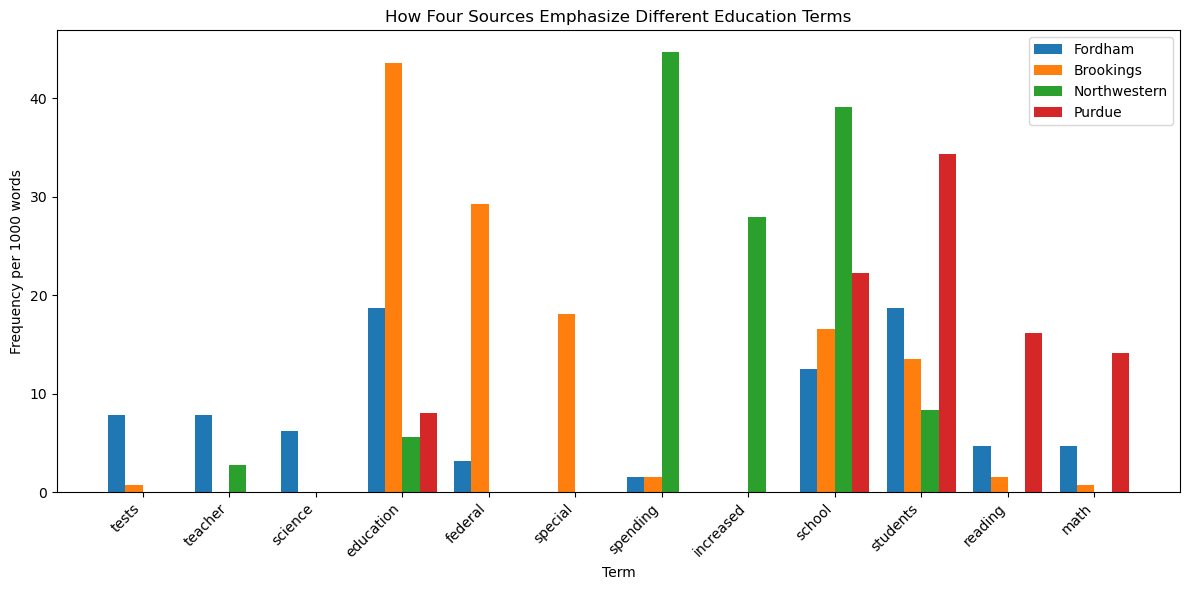

In [232]:
import matplotlib.pyplot as plt 
import numpy as np 

# Pulls the most distinct words from each source so we can reverse engineer from them to find each source's perspective on this problem 
distinct = [] 
for source in normalized: 
    for word, _ in distinct_words(source, n=3): 
        if word not in distinct: 
            distinct.append(word)

sources_list = list(normalized.keys())
x = np.arange(len(distinct))
width = 0.2 

fig, ax = plt.subplots(figsize=(12, 6))
for i, source in enumerate(sources_list): 
    values = [normalized[source].get(term, 0) for term in distinct]
    ax.bar(x + i * width, values, width, label=source) 

ax.set_xlabel("Term")
ax.set_ylabel("Frequency per 1000 words")
ax.set_title("How Four Sources Emphasize Different Education Terms")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(distinct, rotation=45, ha='right')
ax.legend() 
plt.tight_layout()
plt.show()

In [233]:
bad = [(s, w, f) for s in normalized for w, f in normalized[s].items() if isinstance(f, str)]
print(bad) # needed to find bug with distinct_words function it was trying to calculate the average with a string 

[]


In [234]:
import ipywidgets as widgets 
from IPython.display import display, clear_output
import textwrap 

# Descriptions of each paper's position and their proposed solution (if they provide one)
descriptions = {
    "Fordham": "Problem: The structure of the US education system is at fault for low performance. \nSolution: Since the problem is identified in a more general sense, this source doesn't offer one singular solution to solve it.", 
    "Brookings": "Problem: The federal government's role in US education is at fault for low performance. \nSolution: Fix federal programs programs first before policing schools, properly invest in special education programs and remove 'slow learners' from these programs, and create avenues where funding can be sent to schools directly.",
    "Northwestern": "Problem: We are not spending enough money on the public school system. \nSolution: Increase district's per-pupil spending and ensure this increase in spending is going to students and teachers to improve classrooms.", 
    "Purdue": "Problem: The structure of the public education system is at fault for low performance. \nSolution: Government-funded school choice programs, including charter schools, educational savings accounts, and vouchers will fix performance issues."
}

# Creates the dropdown menu where you can pick each source you want to look at 
dropdown = widgets.Dropdown(options=list(normalized.keys()), description="Problem:")

# Where results appear 
output = widgets.Output()

# Every time you choose a source from the dropdown menu, this function is called to update so it displays the new source each time. 
def dropdown_change(change): 
    with output: 
        clear_output() 
        source = change["new"]
        # this needed to be included so text doesn't run off of screen 
        wrapped = textwrap.fill(descriptions[source], width=100)
        print(wrapped)
        print(f"\n Top 10 words ({source}):")
        top = sorted(normalized[source].items(), key=lambda x: x[1], reverse=True)[:10]
        for word, freq in top: 
            print(f" {word}: {freq:.1f}")

dropdown.observe(dropdown_change, names="value")

display(dropdown, output) 

Dropdown(description='Problem:', options=('Fordham', 'Brookings', 'Northwestern', 'Purdue'), value='Fordham')

Output()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output 
import matplotlib.pyplot as plt 
import numpy as np 

sources_names = list(normalized.keys())

"""" Stores the text that will be displayed when you click on each source. It describes each source's identification of what the main issue is with the American education 
and most sources provide their solutions. If the source does not include a solution, then it will say so.""" 

steps = [
    {'title': "The Question", 
     "body": "Four policy papers all diagnose the same problem: low US student performance but disagree sharply on the cause and the fix." 
     "This walkthrough uses word-frequency analysis to show that each author's <b>vocabulary</b> reveals their perspectives on the American education system as a whole and "
     "what they value.", 
     "chart": None}, 
]

for s in sources_names: 
    steps.append({"title": f"{s}'s Argument", "body": descriptions[s], "chart": s})

steps.append({
    "title": "What the Words Reveal", 
    "body": "Each source emphasizes certain words that demonstrate their perspectives on what problems the American education system has."
    " Fordham's emphasis on words is more spread out than other sources, showing that they don't see just one cause for this problem."
    " Brookings has more emphasis on words like 'federal', 'education', 'special', etc. Brookings focuses on the federal government as one of the largest obstacles in American public schools. "
    " Northwestern focuses on words like 'spending', 'increased', and 'school'. This emphasis shows that Northwestern views money as the largest problem for American public schools."
    " Purdue focuses on words like 'students', 'school', 'reading', and 'math'. To Purdue, the problem lies in public school's curriculum and falling performance scores."
    "You can reverse engineer from specific words from each source to figure out what they're arguing.", 
    "chart": "ALL"
})

state = {"i": 0}
out = widgets.Output() 

In [236]:
""" This function creates each bar that is displayed in the finished product. If you choose "ALL" in the window, it will display all distinct words from all sources simultaneously. 
If you don't, then you are able to click through the pages that display each individual source's most distinct words and the bars that show each one. """
def chart_for(source): 
    if source == "ALL": 
        terms = []
        for s in sources:
            for w, _ in distinct_words(s, n=3): 
                if w not in terms: 
                    terms.append(w)
        x = np.arange(len(terms)); width = 0.2 
        fig, ax = plt.subplots(figsize=(11, 5))
        for i, s in enumerate(sources): 
            vals = [normalized[s].get(t, 0) for t in terms]
            ax.bar(x + i * width, vals, width, label=s)
        ax.set_xticks(x + width * 1.5)
        ax.set_xticklabels(terms, rotation=45, ha='right')
        ax.set_ylabel("Frequency per 1000 words")
        ax.set_title("Distinctive Terms Across All Four Sources")
        ax.legend()
    else: 
        top = distinct_words(source, n=8)
        terms = [w for w, _ in top]; vals = [normalized[source].get(t, 0) for t in terms]
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.bar(terms, vals)
        ax.set_xticklabels(terms, rotation=45, ha='right')
        ax.set_ylabel("Frequency per 1000 words")
        ax.set_title(f"{source}: most distinctive terms")
    plt.tight_layout() 
    plt.show()


In [237]:
# This function is setting up the window that you'll see once you go through the walkthrough 
def render(): 
    step = steps[state["i"]]
    with out: 
        clear_output(wait=True)
        display(
            HTML(
                f"<div style='font-family:sans-serif;max-width:720px'>"
                f"<div style='color:#888; font-size:13px'>Step {state['i'] + 1} of {len(steps)}</div>"
                f"<h2 style= 'margin:4px 0'>{step['title']}</h2>"
                f"<p style='font-size: 15px;line-height:1.5'>{step['body']}</p></div>"))
        if step["chart"]:
            chart_for(step["chart"]) 

In [238]:
# These variables are creating and storing the previous and next buttons 
prev_btn = widgets.Button(description="◀ Previous")
next_btn = widgets.Button(description="Next ▶", button_style="primary")

# The go function allows you to step forwards and backwards through the walkthrough 
def go(delta):
    state["i"] = max(0, min(len(steps) - 1, state["i"] + delta))
    render()
prev_btn.on_click(lambda b: go(-1))
next_btn.on_click(lambda b: go(1))

# The jump_to function allows you to jump to any source you want without having to worry about chronological order 
def jump_to(source):
    state["i"] = next(i for i, s in enumerate(steps) if s.get("chart") == source)
    render()

# Creates buttons for each source that you can click on
source_btns = [widgets.Button(description=s) for s in sources]
for b in source_btns:
    b.on_click(lambda btn: jump_to(btn.description))

nav = widgets.HBox([prev_btn, next_btn])
jump = widgets.HBox([widgets.Label("Jump to:")] + source_btns)
display(widgets.VBox([nav, jump, out]))
render()

REFLECTION: 
This project wasn't difficult because of the coding itself, moreso because it was unfamiliar. I don't use Jupyter notebooks at all really so I wasn't sure how different it would be from just a regular .py file. The transition wasn't really too bad though; it's not all that different. Your code just lives in cells instead of one file. Finding the sources and cleaning them up so they could be used for this project wasn't too difficult either. The bugs that came up were pretty easy to fix. There was a massive bug though where the distinct_words() function was trying to do math on a string and it was constantly returning type errors. The intended method for this project was primarily word frequency analysis, so things like preprocessing and text splitting were used, but I have prior experience with this so this wasn't too bad either. The final hurdle was really using the words in order to work backwards to each sources diagnosis of the problem(s) with American public schools. At first I was blanking on this, but it just randomly snapped into place and became easier to write about. Having to think about this project from the perspective of someone who has never coded before was definitely different from my other courses. Usually, we're working under the assumption that everybody already knows the basics of a language/programming from the jump so there's no need to explain too much about how functions work. I hope my comments helped people understand the code for this! 

I did have to move away from my original plan because it was numeric-based and not text-based so a lot of my original plans from the topic statement no longer apply. 